In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# PATHS 
MODEL_PATH = '../models'  # adjust based on your folder structure

# LOAD MODEL AND TRAINING COLUMNS 
lr_model = joblib.load(os.path.join(MODEL_PATH, 'linear_regression_model.pkl'))
train_columns = joblib.load(os.path.join(MODEL_PATH, 'training_columns.pkl'))

In [3]:
# Interpret coeffecients
coeff_df = pd.DataFrame({
    'Feature': train_columns,
    'Coefficient': lr_model.coef_
})

# Sort by absolute impact
coeff_df['AbsCoefficient'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values(by='AbsCoefficient', ascending=False)

# Show top 10 features
print(coeff_df.head(10))

              Feature   Coefficient  AbsCoefficient
239       PoolQC_None  3.538018e+06    3.538018e+06
238         PoolQC_Gd -1.423087e+06    1.423087e+06
127  RoofMatl_Tar&Grv -1.079041e+06    1.079041e+06
126     RoofMatl_Roll -1.078745e+06    1.078745e+06
128  RoofMatl_WdShake -1.073491e+06    1.073491e+06
123  RoofMatl_CompShg -1.071535e+06    1.071535e+06
129  RoofMatl_WdShngl -1.063680e+06    1.063680e+06
125    RoofMatl_Metal -1.023389e+06    1.023389e+06
237         PoolQC_Fa -8.486595e+05    8.486595e+05
247  MiscFeature_TenC  8.198338e+05    8.198338e+05


**Interpret Model Coefficients**
The coefficients show how each feature affects the house price while keeping other features constant.
Positive coefficients indicate that as the feature increases, the house price tends to increase.
Negative coefficients indicate that as the feature increases, the house price tends to decrease.
Features with larger absolute coefficients have a stronger impact on the house price.
Example: If OverallQual has a large positive coefficient, higher overall quality significantly raises the house price.
This helps in understanding which features are most important in predicting house prices and guides business or renovation decisions.

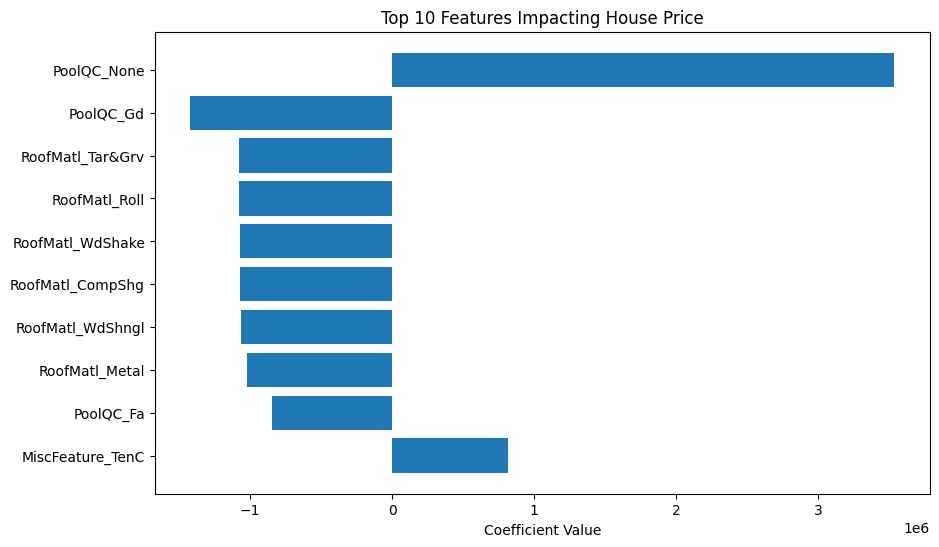

In [ ]:
# Visualization
top_features = coeff_df.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features Impacting House Price')
plt.gca().invert_yaxis()
plt.show()